In [138]:
# Датасет взят отсюда: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing?resource=download

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
df = pd.read_csv(r"C:\Users\user\Downloads\archive\marketing_AB.csv")
df = df.drop(columns=(['Unnamed: 0']))

# EDA

None отсутствуют. Посмотрим на total ads

In [121]:
total_ads_1_quantile = np.quantile(a=df['total ads'], q=0.01)
total_ads_99_quantile = np.quantile(a=df['total ads'], q=0.99)
print(f'Total ads 1 quantile: {total_ads_1_quantile}')
print(f'Total ads 99 quantile: {total_ads_99_quantile}')
print(f'Total ads min: {df['total ads'].min()}')
print(f'Total ads max: {df['total ads'].max()}')
print(f'Total ads mean: {df['total ads'].mean():.2f}')

Total ads 1 quantile: 1.0
Total ads 99 quantile: 202.0
Total ads min: 1
Total ads max: 2065
Total ads mean: 24.82


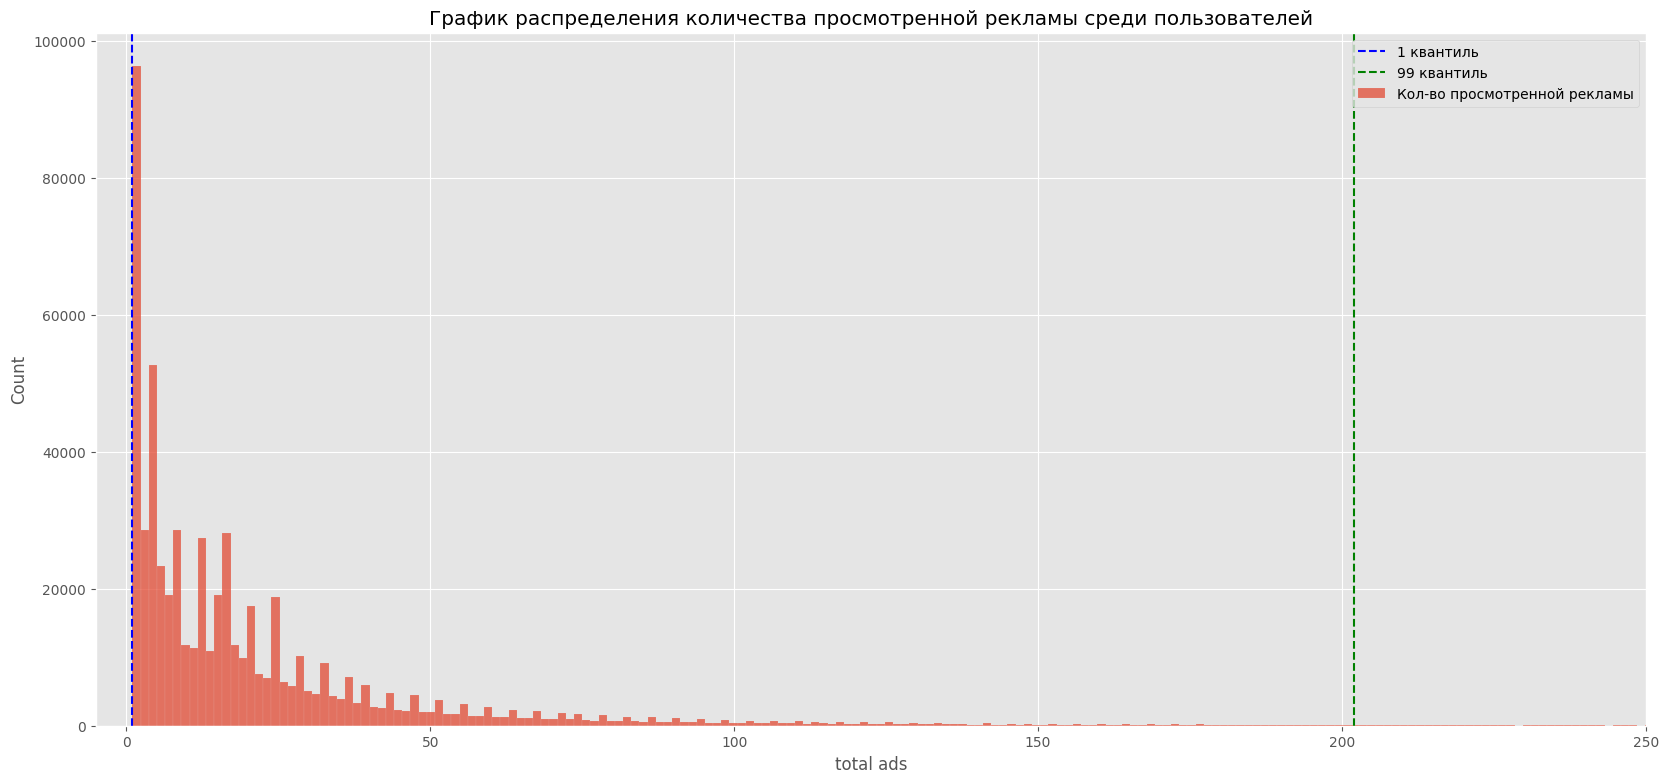

In [122]:
plt.figure(figsize=(20, 9))
sns.histplot(df, x='total ads', label='Кол-во просмотренной рекламы')
plt.xlim(-5, 250)
plt.title('График распределения количества просмотренной рекламы среди пользователей')
plt.axvline(x=total_ads_1_quantile, color='blue', ls='--', label='1 квантиль')
plt.axvline(x=total_ads_99_quantile, color='green', ls='--', label='99 квантиль')
plt.legend(loc='upper right')
plt.show()

Как мы видим, у нас очень много малых значений, поэтому ограничим только сверху 99 квантилем, чтобы избавиться от выбросов.

In [123]:
df = df[df['total ads'] <= total_ads_99_quantile]

 Теперь посмотрим most ads hour

In [124]:
most_ads_hour_1_quantile = np.quantile(a=df['most ads hour'], q=0.01)
most_ads_hour_99_quantile = np.quantile(a=df['most ads hour'], q=0.99)
print(f'Most ads hour 1 quantile: {most_ads_hour_1_quantile}')
print(f'Most ads hour 99 quantile: {most_ads_hour_99_quantile}')
print(f'Most ads hour min: {df['most ads hour'].min()}')
print(f'Most ads hour max: {df['most ads hour'].max()}')
print(f'Most ads hour mean: {df['most ads hour'].mean():.2f}')

Most ads hour 1 quantile: 1.0
Most ads hour 99 quantile: 23.0
Most ads hour min: 0
Most ads hour max: 23
Most ads hour mean: 14.47


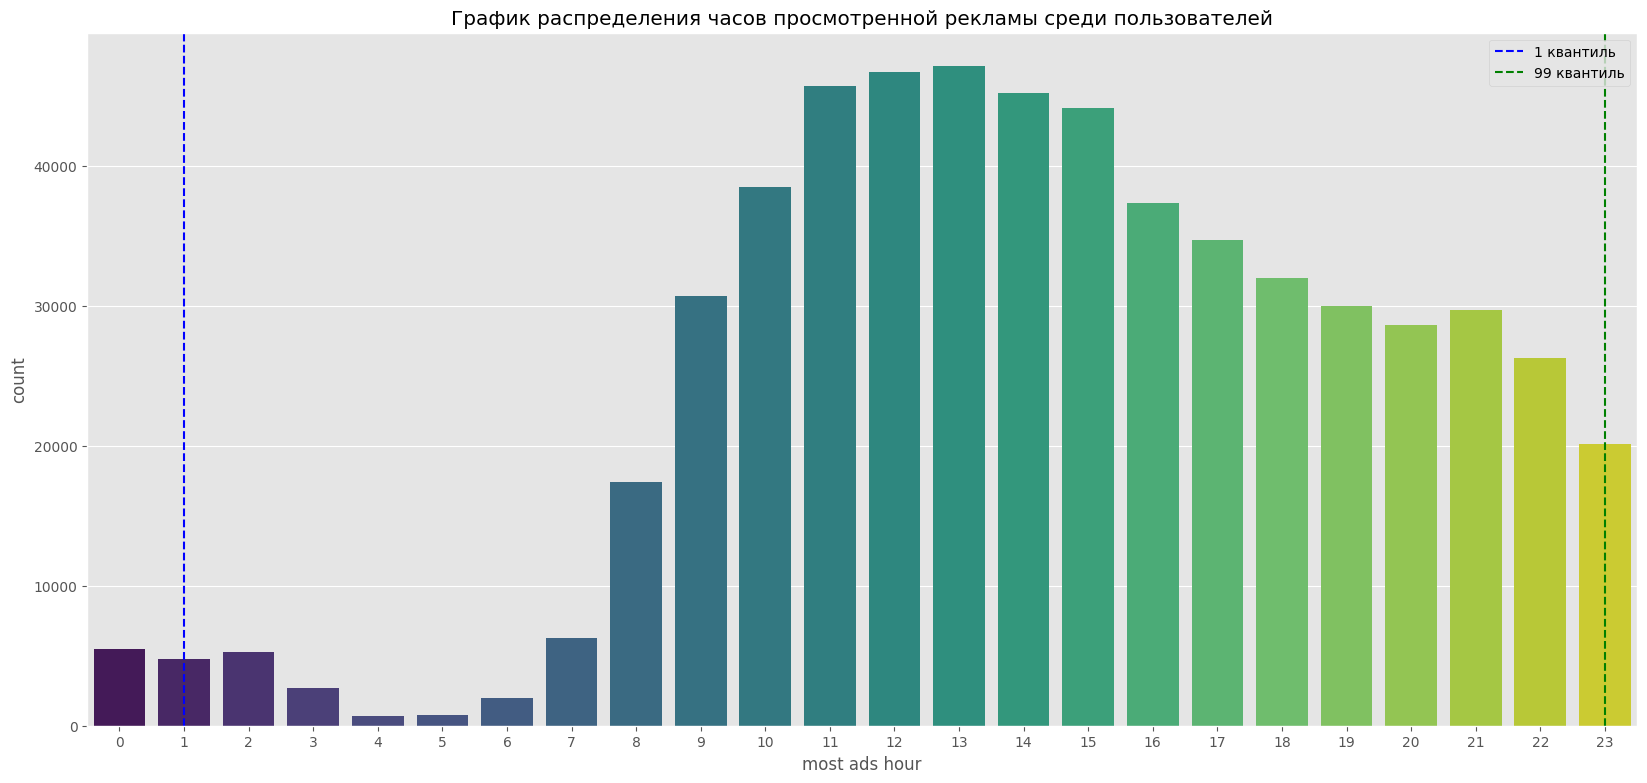

In [125]:
plt.figure(figsize=(20, 9))

sns.countplot(data=df, x='most ads hour', palette='viridis')
plt.title('График распределения часов просмотренной рекламы среди пользователей')
plt.axvline(x=most_ads_hour_1_quantile, color='blue', ls='--', label='1 квантиль')
plt.axvline(x=most_ads_hour_99_quantile, color='green', ls='--', label='99 квантиль')
plt.legend(loc='upper right')
plt.show()

Тут все нормально и не стоит ничего убирать, так как число соответствующих пользователей не малое.
Теперь посмотрим на most ads day

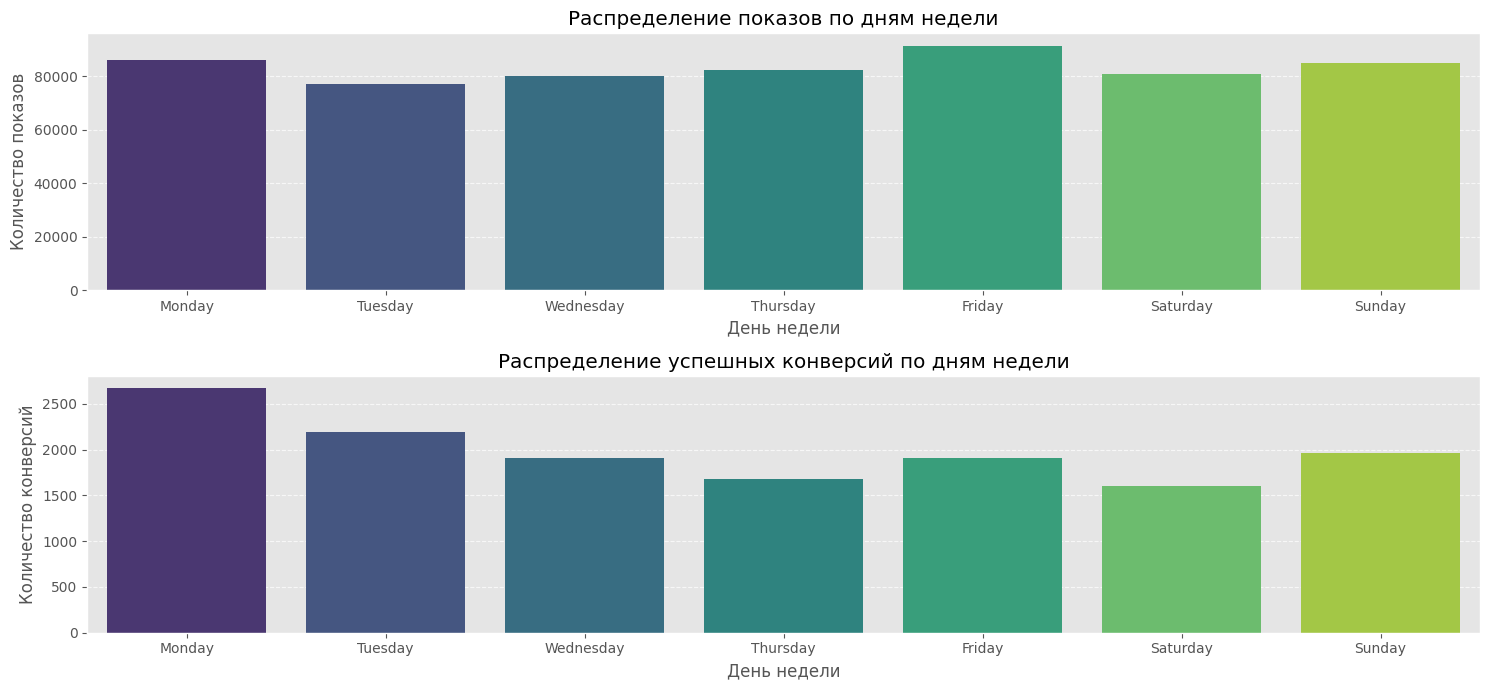

In [126]:
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['most ads day'] = pd.Categorical(df['most ads day'], categories=cats, ordered=True)
df_converted = df[df['converted'] == True]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 7))

sns.countplot(data=df.sort_values(by='most ads day'), x='most ads day', palette='viridis', ax=ax[0])

ax[0].set_title('Распределение показов по дням недели')
ax[0].set_xlabel('День недели')
ax[0].set_ylabel('Количество показов')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(data=df_converted, x='most ads day', palette='viridis', ax=ax[1])

ax[1].set_title('Распределение успешных конверсий по дням недели')
ax[1].set_xlabel('День недели')
ax[1].set_ylabel('Количество конверсий')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Видим достаточно равное распределение у количества показов, при этом в понедельник явно больше конверсий, и в связи с равным распределением понятно, что большая конверсия в понедельник не связана с большим числом показов.

# A/B-test

psa - группа, которой показывали 'социальную рекламу'

ad - группа, которой показывали рекламу

In [127]:
df_ad = df[df['test group'] == 'ad']
df_psa = df[df['test group'] == 'psa']

len_ad = len(df_ad)
len_psa = len(df_psa)

print(f'Количество человек категории AD: {len_ad}, количество человек категории PSA: {len_psa}')

Количество человек категории AD: 559017, количество человек категории PSA: 23274


Можно увидеть тут огромный дисбаланс групп, количество человек категории AD в 24 раза больше количества человек категории PSA

In [128]:
def plot_conversion_by_frequency(df, data_col, target_col, step, title, xlab, ylab):
    '''
    
    '''
    metrics_by_range = {}
    for n in range(step, df[data_col].max() + step, step):
        subset = df[(df[data_col] >= n - step) & (df[data_col] <= n)]
        metrics_by_range[f'{n-step} - {n}'] = subset[target_col].mean()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=metrics_by_range, x=metrics_by_range.keys(), y=metrics_by_range.values(), palette='viridis')
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

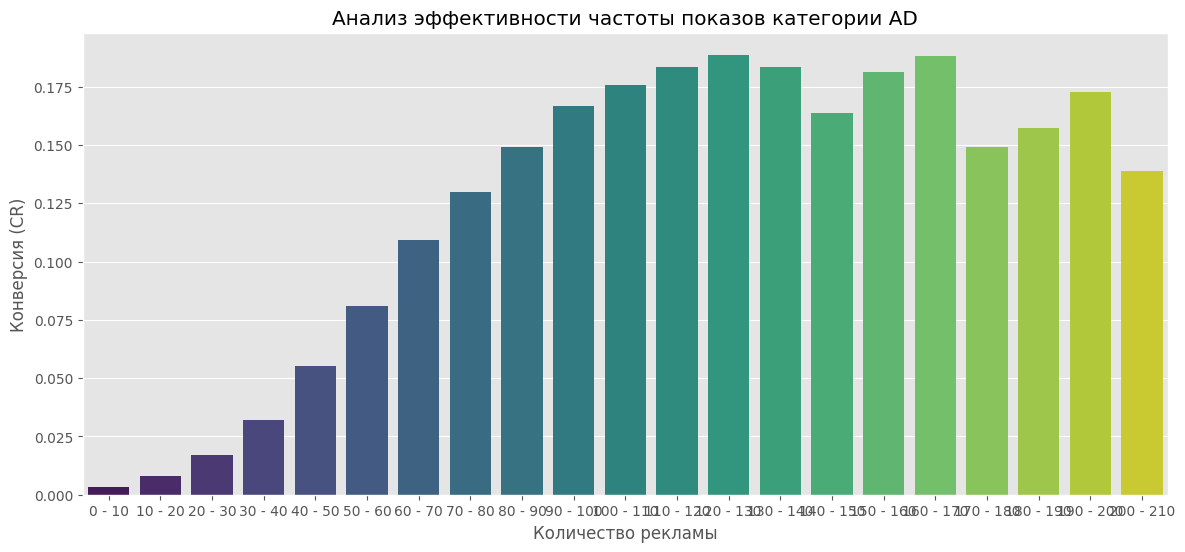

In [129]:
params1 = {
    'data_col': 'total ads',
    'target_col': 'converted',
    'title': 'Анализ эффективности частоты показов категории AD',
    'xlab': 'Количество рекламы',
    'ylab': 'Конверсия (CR)',
    'step': 10
}
plot_conversion_by_frequency(df=df_ad, **params1)

Тут мы видим, что после показа 120 реклам конверсия переходила в плато и начинались некоторые шумы и колебания в конверсии.

Проанализируем конверсию по дням недели для этой категории

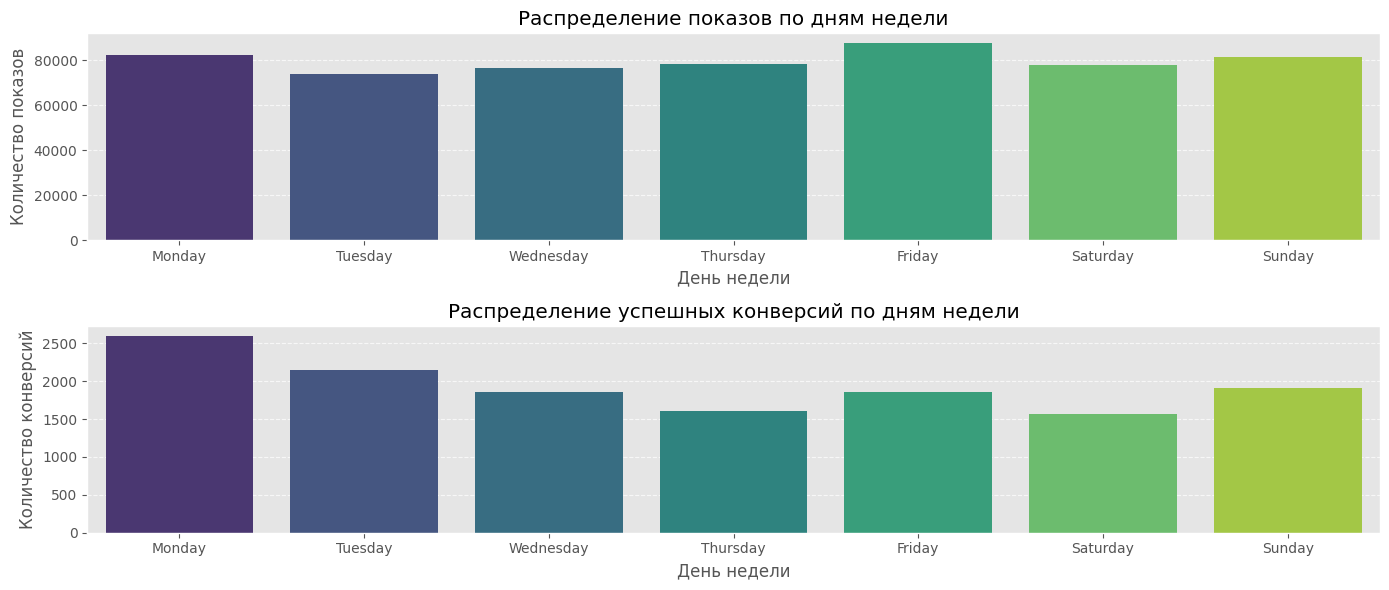

In [130]:
df_converted_ad = df_ad[df_ad['converted'] == True]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 6))

sns.countplot(data=df[df['test group'] == 'ad'].sort_values(by='most ads day'), x='most ads day', palette='viridis', ax=ax[0])

ax[0].set_title('Распределение показов по дням недели')
ax[0].set_xlabel('День недели')
ax[0].set_ylabel('Количество показов')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(data=df_converted_ad, x='most ads day', palette='viridis', ax=ax[1])

ax[1].set_title('Распределение успешных конверсий по дням недели')
ax[1].set_xlabel('День недели')
ax[1].set_ylabel('Количество конверсий')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Видим, что понедельник - самый лучший день, а так же равное распределение по числу показов, что говорит нам о явно большей конверсии в понедельник.

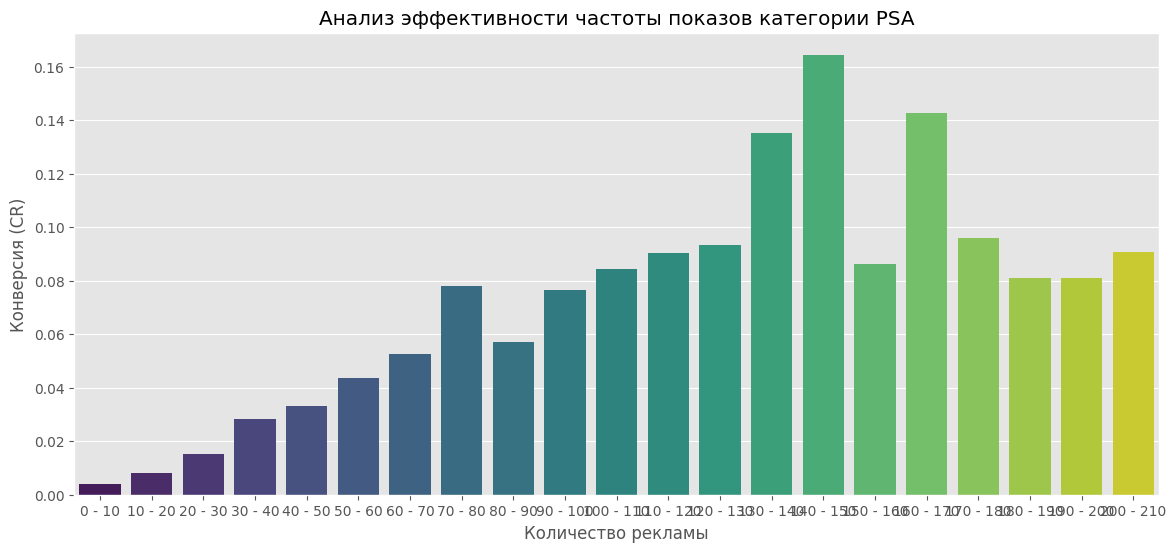

In [131]:
params2 = {
    'data_col': 'total ads',
    'target_col': 'converted',
    'title': 'Анализ эффективности частоты показов категории PSA',
    'xlab': 'Количество рекламы',
    'ylab': 'Конверсия (CR)',
    'step': 10
}
plot_conversion_by_frequency(df=df_psa, **params2)

Тут мы видим стаьиоьный рост до 70-80 социальных реклам, а дальше резкий спад и рост до 140-150 реклам, а дальше плато.

Теперь посмотрим конверсию по дням недели

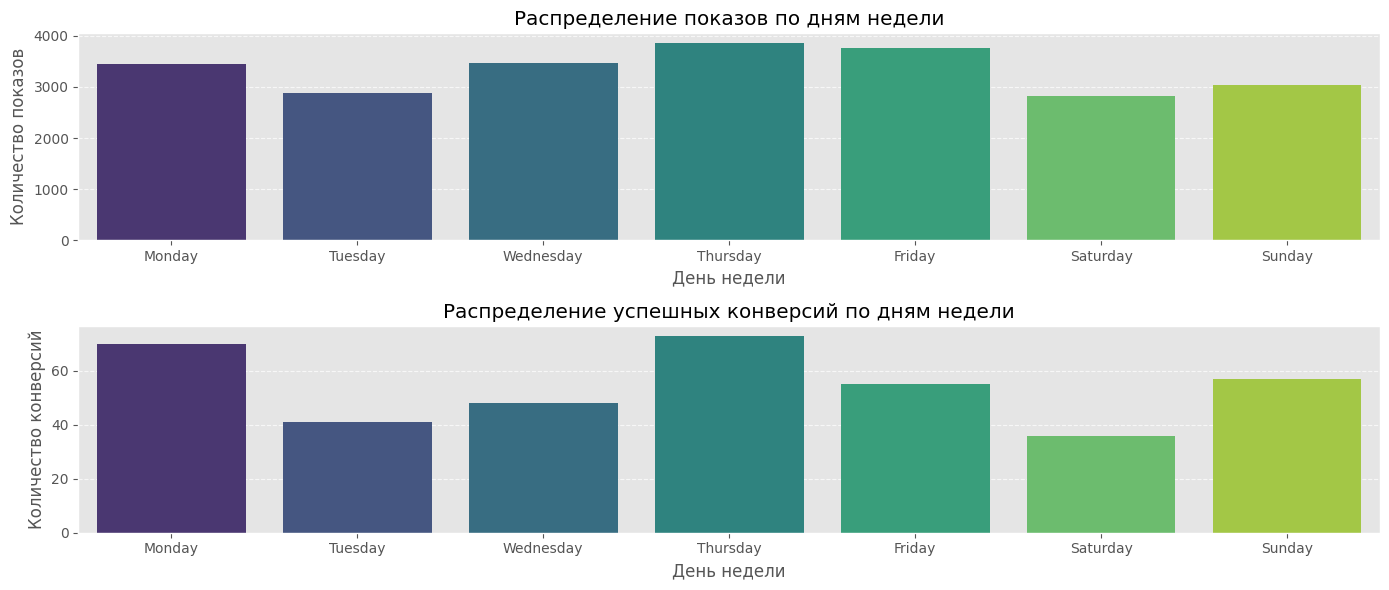

In [132]:
df_converted_psa = df_psa[df_psa['converted'] == True]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 6))

sns.countplot(data=df[df['test group'] == 'psa'].sort_values(by='most ads day'), x='most ads day', palette='viridis', ax=ax[0])

ax[0].set_title('Распределение показов по дням недели')
ax[0].set_xlabel('День недели')
ax[0].set_ylabel('Количество показов')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(data=df_converted_psa, x='most ads day', palette='viridis', ax=ax[1])

ax[1].set_title('Распределение успешных конверсий по дням недели')
ax[1].set_xlabel('День недели')
ax[1].set_ylabel('Количество конверсий')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Тут можно увидеть, что понедельник и четверг имеют самую большую конверсию, в иные дни наблюдаются колеюания, при этом колебания наблюдаются и в числе показов, значит тенденция не гарантирована.

In [133]:
conversion_ad = df_ad['converted'].mean()
conversion_psa = df_psa['converted'].mean()

print(f'Конверсия группы AD: {conversion_ad * 100 :.2f}%')
print(f'Конверсия группы PSA: {conversion_psa * 100:.2f}%')
print(f'Разница в конверсиях AD - PSA: {(conversion_ad - conversion_psa) * 100:.2f}%')

Конверсия группы AD: 2.42%
Конверсия группы PSA: 1.63%
Разница в конверсиях AD - PSA: 0.79%


Мы видим, что конверсия у группы AD больше, чем у группы PSA, на 0.79%. Проверим эти конверсии:

Проведем тест: $H_0: mean_{ad} = mean_{psa}, \ H_1: mean_{ad} > mean_{psa}$

Выберем $\alpha = 0.05$, power=80%

In [134]:
def z_test(Series1, Series2, alpha):
    '''
    H0: Series1.mean() = Series2.mean(),
    H1: Series1.mean() > Series2.mean()
    alpha - уровень значимости
    0 <= alpha <= 1
    '''

    if not (0 <= alpha <= 1):
        raise ValueError('alpha должен лежать в диапозоне от 0 до 1')
    
    if Series1.empty:
        raise ValueError('Series1 не должен быть пустым')

    if Series2.empty:
        raise ValueError('Series2 не должен быть пустым')

    n1 = len(Series1)
    n2 = len(Series2)

    if n1 < 100:
        raise ValueError('В Series1 слишком мало данных, что не подходит для z-test')

    if n2 < 100:
        raise ValueError('В Series2 слишком мало данных, что не подходит для z-test')

    mean1 = Series1.mean()
    std1 = Series1.std()

    mean2 = Series2.mean()
    std2 = Series2.std()

    z_stat = (mean1 - mean2) / (np.sqrt((std1 ** 2 / n1) + (std2 ** 2 / n2)))

    p_value = sps.norm(0, 1).sf(z_stat)

    if p_value < alpha:
        s = 'статистически-значим'
    else:
        s = 'не статистически-значим'

    return z_stat, p_value, s

In [135]:
z_stat, p_value, s = z_test(Series1=df_ad['converted'], Series2=df_psa['converted'], alpha=0.05)
print(f'Результат mean_ad > mean_psa {s}')
print(p_value)

Результат mean_ad > mean_psa статистически-значим
1.0908740139028609e-20


Видим, что есть статистическая значимость в повышении конверсии из-за рекламы, проверим теперь MDE теста

In [136]:
def MDE(Series1, Series2, alpha, power):
    '''
    alpha - уровень значимости
    power - мощность
    0 <= alpha <= 1
    0 <= power <= 1
    '''

    if not (0 <= alpha <= 1):
        raise ValueError('alpha должен лежать в диапозоне от 0 до 1')
    
    if not (0 <= power <= 1):
        raise ValueError('power должен лежать в диапозоне от 0 до 1')
    
    if Series1.empty:
        raise ValueError('Series1 не должен быть пустым')

    if Series2.empty:
        raise ValueError('Series2 не должен быть пустым')

    n1 = len(Series1)
    n2 = len(Series2)

    if n1 < 100:
        raise ValueError('В Series1 слишком мало данных, что не подходит для z-test')

    if n2 < 100:
        raise ValueError('В Series2 слишком мало данных, что не подходит для z-test')

    z_1 = sps.norm(0, 1).ppf(1 - 0.5 * alpha)
    z_2 = sps.norm(0, 1).ppf(power)

    std1 = Series1.std() ** 2 / len(Series1)
    std2 = Series2.std() ** 2 / len(Series2)
    std_ = np.sqrt(std1 + std2)

    return (z_1 + z_2) * std_

In [137]:
mde = MDE(Series1=df_ad['converted'], Series2=df_psa['converted'], alpha=0.05, power=0.8)
print(f'Минимальный детектируемый эффект текста: {mde:.4f}, {(mde / conversion_ad) * 100:.2f}%')

Минимальный детектируемый эффект текста: 0.0024, 9.89%


Из результатов теста и MDE понятно, что тест способен уловить разницу конверсий и показывает достоверные данные о статистической значимости, значит можно считать статистически доказанным верность гипотезы $H_1$